In [17]:
# --- Setup: all imports in one place ---
import glob
import json
import importlib.util
from collections import Counter
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch

In [18]:
from pathlib import Path
RECORDINGS_DIR = Path("recordings-download/*/")
RECORDINGS_BASE = Path("recordings-download/")

score_r1 = "cf_score_p15.json"
score_r2 = "cf_score_pw4p6.json"
post_survey_1 = "post_survey_p15.json"
post_survey_2 = "post_survey_pw4p6.json"

In [19]:
# Participants who had both r1 and r2
all_r1 = glob.glob(str(RECORDINGS_DIR / score_r1))
all_r1 = [x.split("/")[-2] for x in all_r1]
all_r2 = glob.glob(str(RECORDINGS_DIR / score_r2))
all_r2 = [x.split("/")[-2] for x in all_r2]

all_candidates = set(all_r1).intersection(set(all_r2))
all_candidates

{'p542',
 'p780',
 'p848',
 'p591',
 'p509',
 'p219',
 'p56',
 'p214',
 'p688',
 'p258',
 'p706',
 'p838',
 'p286',
 'p84',
 'p182',
 'p556',
 'p727',
 'p349',
 'p101',
 'p662',
 'p543',
 'p153',
 'p315',
 'p672',
 'p21',
 'p753',
 'p212',
 'p687',
 'p379',
 'p788',
 'p633',
 'p280',
 'p32',
 'p355',
 'testtest'}

In [20]:
all_candidates.remove("testtest")

In [21]:
len(all_candidates)

34

# Separate Optimal Moves >= 2 vs. The Rest

In [22]:
# Merged 2-group split: good = score >= 2 (former win + good), bad = the rest.
good_pid, bad_pid = [], []
win_pid = []   # merged into good; kept empty so any legacy references still work
for pid in all_candidates:
    curr_f = json.load(open(RECORDINGS_BASE / pid / score_r2))
    if curr_f["score"] >= 2:
        good_pid.append(pid)
    else:
        bad_pid.append(pid)

In [23]:
len(good_pid), len(bad_pid)

(21, 13)

# Score Differences

In [24]:
# Mean / median / std for a field, across a set of participants.
# nasa_tlx=True reads post_survey["nasa_tlx"][field] instead of a top-level field.
import os
def report_avg(fn, kn, cands=all_candidates, nasa_tlx=False):
    vals = []
    for pid in cands:
        d = json.load(open(RECORDINGS_BASE / pid / fn))
        try:
            vals.append(d["nasa_tlx"][kn] if nasa_tlx else int(d[kn]))
        except ValueError:
            vals.append(0)
    return np.mean(vals), np.median(vals), np.std(vals)

# Round-level score summary across all completers
print(f"{'round':>10} {'metric':>14} {'mean':>6} {'median':>7} {'std':>6}")
for rlabel, fn in [("R1 (AI)", score_r1), ("R2 (no AI)", score_r2)]:
    for kn, name in [("score", "Board"), ("winning_line_score", "Solution")]:
        m, md, sd = report_avg(fn, kn)
        print(f"{rlabel:>10} {name:>14} {m:>6.2f} {md:>7.1f} {sd:>6.2f}")

     round         metric   mean  median    std
   R1 (AI)          Board   1.32     1.0   0.83
   R1 (AI)       Solution   0.50     0.0   0.81
R2 (no AI)          Board   1.62     2.0   0.91
R2 (no AI)       Solution   0.76     0.0   1.11


# Demographic Differences

In [9]:
report_avg("demographics.json", "skill_rating", cands=good_pid + win_pid)

(np.float64(1.9), np.float64(2.0), np.float64(0.7000000000000001))

In [10]:
report_avg("demographics.json", "skill_rating", cands=bad_pid)

(np.float64(1.7692307692307692),
 np.float64(2.0),
 np.float64(0.5756395979652217))

In [11]:
report_avg("demographics.json", "age", cands=good_pid + win_pid)

(np.float64(41.9), np.float64(41.5), np.float64(10.601414999895061))

In [12]:
report_avg("demographics.json", "age", cands=bad_pid)

(np.float64(41.07692307692308),
 np.float64(37.0),
 np.float64(13.430513699216872))

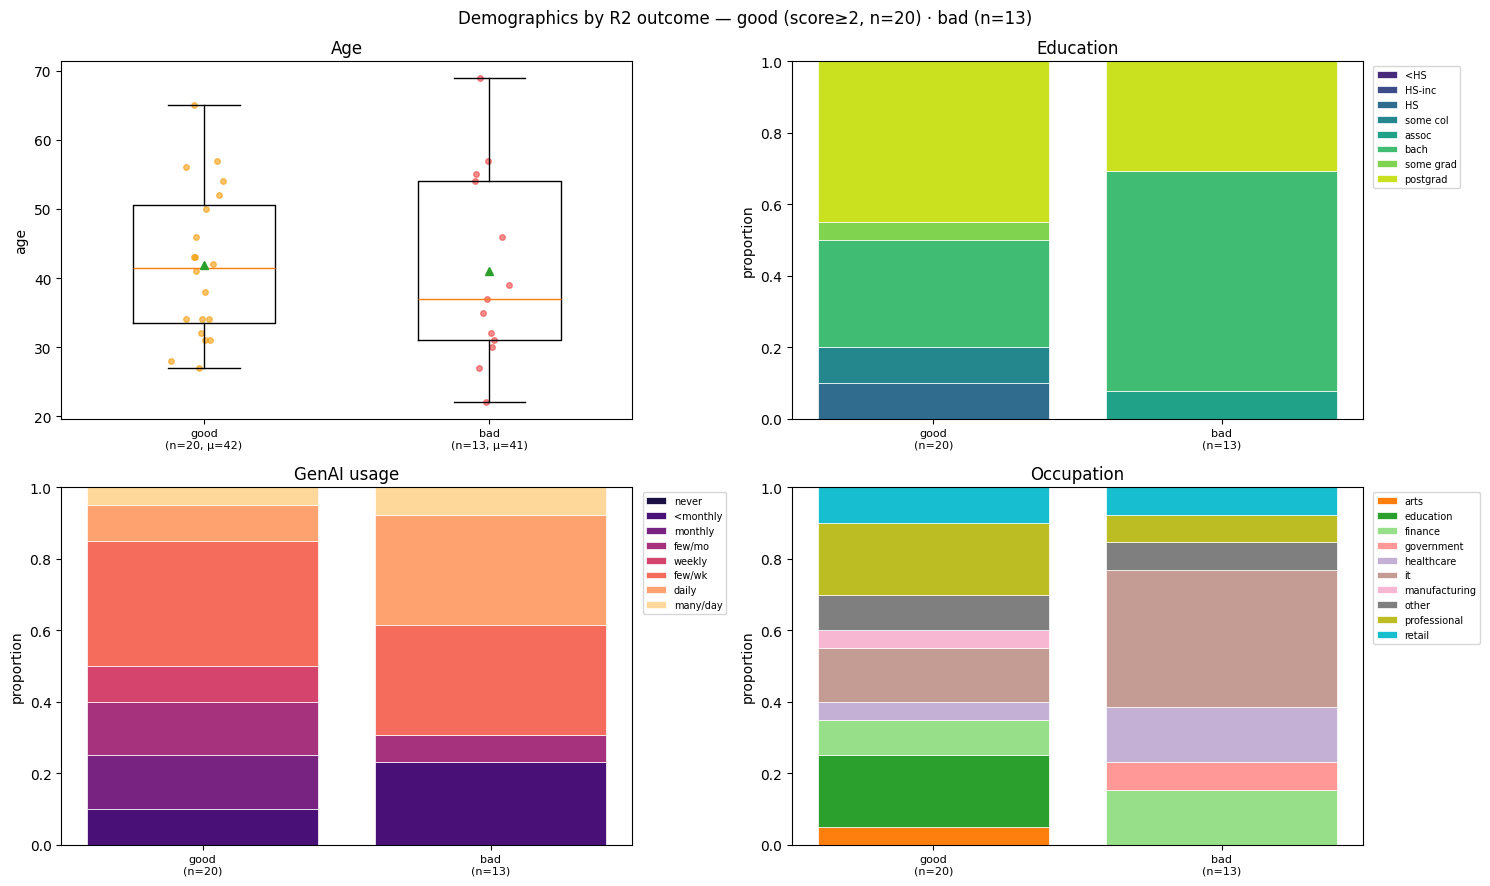

In [13]:
# --- Demographics: good_pid vs win_pid vs bad_pid ---
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

def load_demo(cands):
    return [json.load(open(RECORDINGS_BASE / pid / "demographics.json"))
            for pid in cands if (RECORDINGS_BASE / pid / "demographics.json").exists()]

dg, dw, db = load_demo(good_pid), load_demo(win_pid), load_demo(bad_pid)
GROUPS = [("good", dg, "#f59e0b"), ("bad", db, "#ef4444")]

# Ordered categories (app option order) + short labels
EDU = (["less_than_hs","hs_incomplete","hs_graduate","some_college","associate","bachelors","some_postgrad","postgrad"],
       ["<HS","HS-inc","HS","some col","assoc","bach","some grad","postgrad"])
GEN = (["never","less_than_monthly","about_monthly","few_times_month","weekly","few_times_week","daily","several_times_day"],
       ["never","<monthly","monthly","few/mo","weekly","few/wk","daily","many/day"])

def props(demos, key, order):
    n = sum(1 for d in demos if d.get(key) in order) or 1
    c = Counter(d.get(key) for d in demos)
    return np.array([c.get(o, 0) / n for o in order])

def stacked(a, key, order, short, title, cmap="viridis"):
    x = np.arange(len(GROUPS))
    P = np.array([props(d, key, order) for _, d, _ in GROUPS])   # (3 groups, n_cats)
    colors = plt.get_cmap(cmap)(np.linspace(0.12, 0.92, len(order)))
    bottoms = np.zeros(len(GROUPS))
    for ci, lab in enumerate(short):
        a.bar(x, P[:, ci], bottom=bottoms, color=colors[ci], label=lab, edgecolor="white", lw=0.5)
        bottoms += P[:, ci]
    a.set_xticks(x); a.set_xticklabels([f"{nm}\n(n={len(d)})" for nm, d, _ in GROUPS], fontsize=8)
    a.set_ylim(0, 1); a.set_ylabel("proportion"); a.set_title(title)
    a.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)

fig, ax = plt.subplots(2, 2, figsize=(15, 9))

# Age — box + jittered points per group
ages = [[d["age"] for d in demos if d.get("age")] for _, demos, _ in GROUPS]
ax[0,0].boxplot(ages, positions=range(len(GROUPS)), widths=0.5, showmeans=True)
rng = np.random.default_rng(0)
for i, ((nm, _, col), v) in enumerate(zip(GROUPS, ages)):
    ax[0,0].scatter(rng.normal(i, 0.05, len(v)), v, s=16, alpha=0.6, color=col)
ax[0,0].set_xticks(range(len(GROUPS)))
ax[0,0].set_xticklabels([f"{nm}\n(n={len(v)}, μ={np.mean(v):.0f})" for (nm,_,_), v in zip(GROUPS, ages)], fontsize=8)
ax[0,0].set_ylabel("age"); ax[0,0].set_title("Age")

stacked(ax[0,1], "education", *EDU, "Education", cmap="viridis")
stacked(ax[1,0], "genai_usage", *GEN, "GenAI usage", cmap="magma")
occ = sorted({d.get("occupation") for _, dm, _ in GROUPS for d in dm if d.get("occupation")})
stacked(ax[1,1], "occupation", occ, occ, "Occupation", cmap="tab20")

fig.suptitle("Demographics by R2 outcome — good (score≥2, n=%d) · bad (n=%d)"
             % (len(dg), len(db)), fontsize=12)
plt.tight_layout(); plt.show()

# NASA-TLX Differences

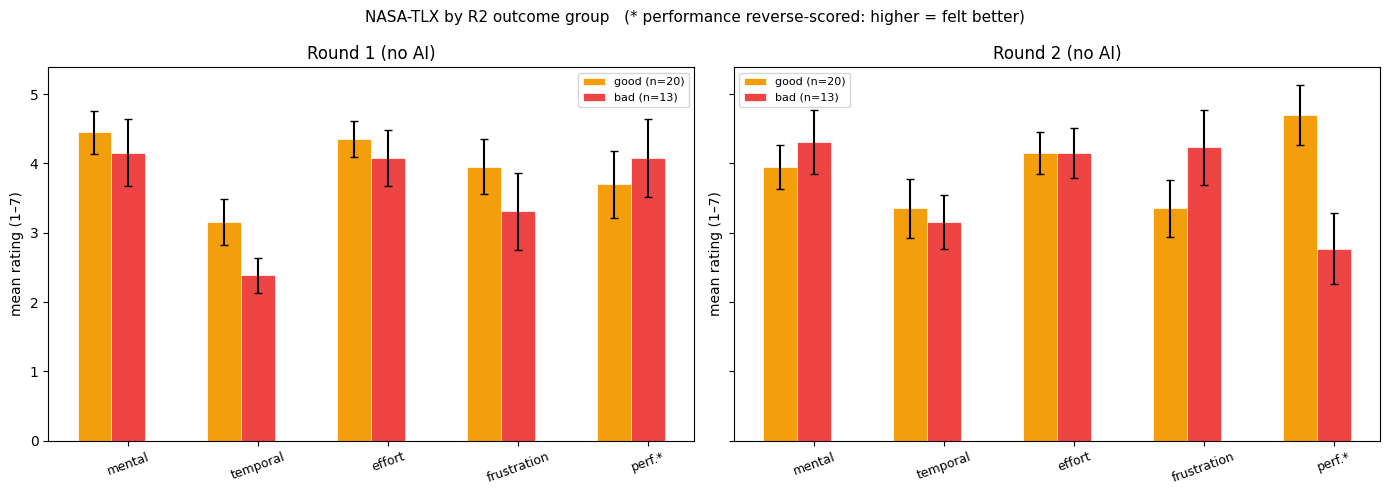

In [14]:
# --- NASA-TLX by R2 outcome group (good / win / bad), per round ---
# physical_demand was dropped from the instrument (present in only some batch-1
# files), so we compare the 5 current items. performance is reverse-scored:
# a HIGHER rating means the participant felt they did BETTER (lower workload).
TLX_ITEMS = ["mental_demand", "temporal_demand", "effort", "frustration", "performance"]
TLX_SHORT = ["mental", "temporal", "effort", "frustration", "perf.*"]
GROUPST = [("good", good_pid, "#f59e0b"), ("bad", bad_pid, "#ef4444")]
ROUNDS = [("Round 1 (no AI)", post_survey_1), ("Round 2 (no AI)", post_survey_2)]

fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
x = np.arange(len(TLX_ITEMS)); w = 0.26
for a, (rlabel, sfile) in zip(ax, ROUNDS):
    for gi, (nm, pids_, col) in enumerate(GROUPST):
        s = [report_avg(sfile, it, cands=pids_, nasa_tlx=True) for it in TLX_ITEMS]
        means = [v[0] for v in s]
        sems = [v[2] / np.sqrt(len(pids_)) for v in s]      # std error of the mean
        a.bar(x + (gi - 1) * w, means, w, yerr=sems, capsize=3, color=col,
              label=f"{nm} (n={len(pids_)})", edgecolor="white", lw=0.5)
    a.set_xticks(x); a.set_xticklabels(TLX_SHORT, rotation=20, fontsize=9)
    a.set_title(rlabel); a.set_ylabel("mean rating (1–7)"); a.legend(fontsize=8)
fig.suptitle("NASA-TLX by R2 outcome group   (* performance reverse-scored: higher = felt better)",
             fontsize=11)
plt.tight_layout(); plt.show()

# Time per Puzzle

In [15]:
import os
import datetime

def _ts(s):
    return datetime.datetime.fromisoformat(s)

def measure_time(pids):
    times = []
    for pid in pids:
        moves_f  = RECORDINGS_BASE / pid / "moves_p15.jsonl"
        prompt_f = RECORDINGS_BASE / pid / "prompt_task.json"
        if os.path.exists(moves_f) and os.path.exists(prompt_f):
            lines = [json.loads(l) for l in open(moves_f) if l.strip()]
            start = _ts(json.load(open(prompt_f))["submitted_at"])   # approx puzzle start
            end   = _ts(lines[-1]["ts"])                             # last move
            times.append((end - start).total_seconds())
        else:
            times.append(None)
    times = [x for x in times if x is not None]
    return np.mean(times), np.median(times), np.std(times),  max(times), min(times)

measure_time(good_pid + bad_pid)


(np.float64(90.5913022121212),
 np.float64(70.697701),
 np.float64(50.82931816622623),
 256.809831,
 42.738082)

In [16]:
import os
import datetime

def _ts(s):
    return datetime.datetime.fromisoformat(s)

def measure_time(pids):
    times = []
    for pid in pids:
        moves_f  = RECORDINGS_BASE / pid / "moves_pw4p6.jsonl"
        prompt_f = RECORDINGS_BASE / pid / "post_survey_p15.json"
        if os.path.exists(moves_f) and os.path.exists(prompt_f):
            lines = [json.loads(l) for l in open(moves_f) if l.strip()]
            start = _ts(json.load(open(prompt_f))["submitted_at"])   # approx puzzle start
            end   = _ts(lines[-1]["ts"])                             # last move
            times.append((end - start).total_seconds())
        else:
            times.append(None)
    times = [x for x in times if x is not None]
    return np.mean(times), np.median(times), np.std(times), max(times), min(times)

measure_time(good_pid + bad_pid)


(np.float64(57.884316000000005),
 np.float64(45.219791),
 np.float64(38.252303019427785),
 218.959346,
 17.270594)